In [66]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from functools import reduce

In [67]:
co2_injection_scenario = "min_co2_injection"
cases = ["noemissionscap", "30pct", "60pct", "80pct"]
flow_dfs = {}

for case in cases:
    flows = pd.read_csv("results/" + co2_injection_scenario + "/" + case + "/results/flows.csv")
    flow_dfs[case] = flows


In [68]:
def get_flow_sums_by_tech(
    flow_df,
    include_keywords=None,     # list of substrings to keep column names
    drop_techs=None            # list of tech names to drop
):
    """
    Build a Region × Technology CO₂ emissions table (Region = rows).
    """

    # --- 1. Select columns ---
    if include_keywords is not None:
        co2_cols = [
            c for c in flow_df.columns
            if any(kw in c for kw in include_keywords)
        ]
    else:
        # Match any column containing both "co2" and "edge" regardless of order/position
        co2_cols = [
            c for c in flow_df.columns
            if "co2" in c.lower() and "edge" in c.lower()
        ]

    # --- Region sort ---
    def region_sort_key(name):
        match = re.search(r"Region(\d+)", name)
        return int(match.group(1)) if match else 999

    co2_cols = sorted(co2_cols, key=region_sort_key)

    # --- 2. Sum flows across time ---
    co2_sums = flow_df[co2_cols].sum()

    # --- 3. Extract Region and Technology names in one pass ---
    full_pattern = re.compile(r"Region\d+([A-Za-z]+)_(.*)")

    rows = []
    for col, val in co2_sums.items():
        m = full_pattern.search(col)
        if m:
            rows.append({"Region": m.group(1), "Technology": m.group(2), "Value": val})

    df = pd.DataFrame(rows)

    co2_by_region_tech = df.pivot_table(
        index="Region",
        columns="Technology",
        values="Value",
        aggfunc="sum"
    )

    co2_by_region_tech = co2_by_region_tech[
        sorted(co2_by_region_tech.columns, key=lambda x: x.lower())
    ]

    # --- 4. Drop unwanted technologies ---
    if drop_techs is not None:
        existing = [t for t in drop_techs if t in co2_by_region_tech.columns]
        co2_by_region_tech = co2_by_region_tech.drop(columns=existing)

    return co2_by_region_tech

In [69]:
co2_by_region_tech_dict = {}
co2_all_china_by_tech = pd.DataFrame()

for case in cases:
    co2_by_region_tech = get_flow_sums_by_tech(
    flow_dfs[case],
    include_keywords=["co2_edge", "co2_emissions_edge"],
    drop_techs=["nuclear_co2_edge", "oxyfuelcement_co2_emissions_edge"]
)   
    co2_by_region_tech_dict[case] = co2_by_region_tech
    co2_all_china_by_tech[case] = co2_by_region_tech.sum()

In [70]:
co2_all_china_by_tech

,noemissionscap,30pct,60pct,80pct
Technology,,,,
aluminum_smelting_co2_edge,2.171855e+06,2.171877e+06,2.171856e+06,2.171882e+06
bfbof_co2_edge,5.252261e+07,5.252269e+07,1.596010e+07,3.221800e+01
bfbofccs_co2_edge,7.627956e-02,1.150578e-01,1.175086e+00,4.454138e-01
bfbofccs_retrofit_co2_edge,2.041922e-01,3.229910e-01,1.954020e+00,5.491213e-01
coal_co2_edge,2.820714e+08,1.081222e+08,7.112325e+03,1.002704e+04
drieaf_co2_edge,7.557466e+00,2.763913e+00,7.600931e+05,1.206441e+06
drieaf_retrofit_co2_edge,1.111564e-01,2.413629e+00,3.116898e+05,3.116880e+05
gasdri_co2_edge,1.446973e+01,3.632482e+01,4.273989e+01,1.783030e+02
gasdriccs_co2_edge,5.266494e-02,2.165077e-01,2.454192e-01,3.674947e-01


# Plot CO2 Emissions by Region and Tech

In [71]:
scenario_map = {
    "noemissionscap": "No Emissions Policy",
    "30pct": "30% Emissions Reduction",
    "60pct": "60% Emissions Reduction",
    "80pct": "80% Emissions Reduction"
}


In [72]:
# Make Name Map
tech_name_map = {
    # Cement
    "oxyfuelcement_retrofit_co2_emissions_edge": "Oxyfuel Cement Retrofit",
    "meacement_co2_emissions_edge": "MEA Cement Retrofit",
    "tradcement_co2_emissions_edge": "Traditional Cement",

    # Steel (BF-BOF and Scrap EAF)
    "bfbof_co2_edge": "BF-BOF",
    "bfbofccs_co2_edge": "BF-BOF-CCS",
    "bfbofccs_retrofit_co2_edge": "BF-BOF-CCS Retrofit",
    "scrapeaf56_co2_edge": "Scrap EAF 56%",
    "scrapeaf100_co2_edge": "Scrap EAF 100%",
    "scrapeaf100_retrofit_co2_edge": "Scrap EAF 100% Retrofit",

    # Steel (DRI Routes)
    "drieaf_co2_edge": "DRI-EAF",
    "drieaf_retrofit_co2_edge": "DRI-EAF Retrofit",
    "gasdri_co2_edge": "Gas DRI",
    "gasdriccs_co2_edge": "Gas DRI with CCS",
    "h2dri_co2_edge": "H2 DRI",

    # Aluminum
    "aluminum_smelting_co2_edge": "Aluminum Smelting",

    # Power & Energy
    "coal_co2_edge": "Coal Power",
    "naturalgas_power_co2_edge": "Natural Gas Power",
}

In [73]:
custom_color_map = {
    "Oxyfuel Cement Retrofit": "#ff9d9a",
    "MEA Cement Retrofit": "#f28e9b",
    "Traditional Cement": "#e15759",

    # Steel - Primary & Scrap
    "BF-BOF": "#1f77b4",
    "BF-BOF-CCS": "#0ee3ff",
    "BF-BOF-CCS Retrofit": "#aec7e8",
    "Scrap EAF 56%": "#38a938",
    "Scrap EAF 100%": "#6acaa2",
    "Scrap EAF 100% Retrofit": "#98df8a",

    # Steel - DRI Routes
    "DRI-EAF": "#9467bd",
    "DRI-EAF Retrofit": "#c5b0d5",
    "Gas DRI": "#8c564b",
    "Gas DRI with CCS": "#e377c2",
    "H2 DRI": "#17becf",

    # Aluminum
    "Aluminum Smelting": "#bbbbb2",

    # Power
    "Natural Gas Power": "#eb7a23",
    "Coal Power": "#4a5568",

    "Hydropower": "#3e6496",
    "Solar PV (Centralized)":"#fbb04e",
    "Solar PV (Distributed)": "#f1ce63",
    "Wind (Offshore)": "#638fbb",
    "Wind (Onshore)": "#90bfe2",
    "Battery Storage": "#9f6490",
    "Nuclear": "#3c8782",
    "Pumped Hydro Storage": "#75afa7"
}


In [74]:
import plotly.express as px
import pandas as pd

def plot_stacked_bar(
    df,
    scenario_map=None,      # maps scenario/column names to pretty names
    name_map=None,          # maps technology names (index) to pretty names
    color_map=None,         # maps pretty tech names --> colors
    title_name="none",
    xaxis_name="none",
    yaxis_name="none",
    width=1200,
    height=600,
):
    """
    Create a stacked bar plot where:
      - each COLUMN of df becomes a bar (scenario)
      - each ROW/index becomes a stacked segment (technology)

    New features:
      • scenario_map: dict mapping df column → label
      • title_name, xaxis_name, yaxis_name: optional labels (default = "none")
    """

    # --- Apply scenario_map to rename incoming bar labels ---
    if scenario_map:
        df = df.rename(index=scenario_map)

    # Transpose so that each scenario becomes one bar
    df = df.T

    # Ensure the index has a name
    if not df.index.name:
        df = df.copy()
        df.index.name = "Category"

    row_label = df.index.name

    # Convert to long format
    df_long = df.reset_index().melt(
        id_vars=row_label,
        var_name="Scenario",
        value_name="Value"
    )

    # --- Apply name_map to legend entries (index entries) ---
    display_col = row_label + "_Display"

    if name_map:
        df_long[display_col] = df_long[row_label].map(lambda x: name_map.get(x, x))
    else:
        df_long[display_col] = df_long[row_label]

    # --- If color_map is provided, remap using the display names ---
    if color_map and name_map:
        color_map = {name_map.get(k, k): v for k, v in color_map.items()}

    fig = px.bar(
        df_long,
        x="Scenario",
        y="Value",
        color=display_col,
        title=None if title_name == "none" else title_name,
        labels={
            "Scenario": xaxis_name if xaxis_name != "none" else "Scenario",
            "Value": yaxis_name if yaxis_name != "none" else "Value",
            display_col: row_label
        },
        color_discrete_map=color_map,
    )

    fig.update_layout(
        barmode="stack",
        template="plotly_white",
        width=width,
        height=height,
        margin=dict(l=60, r=60, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)
    return fig


In [75]:
plot_stacked_bar(
    df = co2_all_china_by_tech.T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name="",
    xaxis_name="Emissions Scenario",
    yaxis_name="National CO2 Emissions (Tonnes)",
    width=700)

In [76]:
from plotly.subplots import make_subplots

def plot_scenario_subplots(
    co2_dict,
    scenario_map,            # dict: scenario_key -> display label
    name_map=None,
    color_map=None,
    ymax=30e6,
    ncols=None,
    title_prefix="",
    xaxis_name="none",
    yaxis_name="none",
    width=2500
):
    keys = list(co2_dict.keys())
    n = len(keys)

    if ncols is None:
        ncols = n

    # ---- Create subplot grid ----
    fig = make_subplots(
        rows=1,
        cols=ncols,
        subplot_titles=[f"{title_prefix}{scenario_map[k]}" for k in keys],
        horizontal_spacing=0.05,
    )

    # ---- Loop through scenarios ----
    for col_idx, key in enumerate(keys, start=1):
        df = co2_dict[key]

        # Build stacked bar chart WITHOUT axis titles (we add them manually)
        subfig = plot_stacked_bar(
            df,
            scenario_map=scenario_map,
            name_map=name_map,
            color_map=color_map,
            title_name="none",
            xaxis_name="none",
            yaxis_name="none"
        )

        # Add each trace into its subplot
        for trace in subfig.data:
            trace.showlegend = (col_idx == 1)   # only show legend in first
            fig.add_trace(trace, row=1, col=col_idx)

        # Set y-range
        fig.update_yaxes(range=[0, ymax], row=1, col=col_idx)

    # ---- Add AXIS TITLES manually (important) ----
    # y-axis title only on the first subplot
    if yaxis_name != "none":
        fig.update_yaxes(title_text=yaxis_name, row=1, col=1)

    # x-axis titles on each subplot
    if xaxis_name != "none":
        for col_idx in range(1, ncols+1):
            fig.update_xaxes(title_text=xaxis_name, row=1, col=col_idx)

    # ---- Layout ----
    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        height=650,
        width=width,
        legend_title="Category",
        margin=dict(l=40, r=40, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)

    return fig


In [77]:
co2_by_region_tech_dict['30pct']

Technology,aluminum_smelting_co2_edge,bfbof_co2_edge,bfbofccs_co2_edge,bfbofccs_retrofit_co2_edge,coal_co2_edge,drieaf_co2_edge,drieaf_retrofit_co2_edge,gasdri_co2_edge,gasdriccs_co2_edge,h2dri_co2_edge,meacement_co2_emissions_edge,meacement_retrofit_co2_emissions_edge,naturalgas_power_co2_edge,oxyfuelcement_retrofit_co2_emissions_edge,scrapeaf100_co2_edge,scrapeaf100_retrofit_co2_edge,scrapeaf56_co2_edge,tradcement_co2_emissions_edge
Region,,,,,,,,,,,,,,,,,,
Anhui,87508.085580,1.864113e+06,0.003981,0.011168,5.737390e+06,0.007388,0.079924,1.262874,0.006725,0.0,0.0,0.273424,1.861487e+06,0.019708,0.008101,12678.373652,67.400194,3.397257e+06
Beijing,49.081940,3.204962e+06,0.003962,0.011126,4.810679e+02,0.013715,0.085792,1.298881,0.008102,0.0,0.0,0.274010,1.911141e+06,0.028901,0.004796,9862.763880,53.517200,6.652671e+04
Chongqing,20377.775208,6.545775e+05,0.003993,0.011204,6.606124e+05,0.064815,0.093537,1.300705,0.009847,0.0,0.0,0.279139,1.691626e+06,0.007582,0.026595,2434.938536,12491.754036,1.538595e+06
Fujian,33867.088843,1.450538e+06,0.003950,0.011061,2.320822e+06,0.004745,0.133351,1.179583,0.002126,0.0,0.0,0.274904,2.116396e+06,0.009888,0.009009,25772.636427,350.806216,2.299371e+06
Gansu,161932.239991,5.745793e+05,0.003981,0.011198,2.547437e+06,0.012963,0.091115,1.299092,0.011002,0.0,0.0,0.280948,8.254846e+05,0.006536,0.008143,1867.383191,17306.373394,1.139762e+06
Guangdong,22251.237235,1.662849e+06,0.003950,0.011019,1.496922e+07,0.003722,0.134416,1.138231,0.002179,0.0,0.0,0.263756,4.089986e+06,0.021603,0.007798,896.326461,344874.896606,3.374758e+06
Guangxi,166425.615836,2.176058e+06,0.003943,0.011057,2.785692e+06,0.003391,0.166334,1.188811,0.002116,0.0,0.0,0.273581,2.084115e+06,0.006051,0.008317,4.561120,478749.666188,3.445700e+06
Guizhou,63583.412964,2.012537e+05,0.003994,0.011192,3.910603e+06,0.047728,0.136727,1.294891,0.007250,0.0,0.0,0.277312,6.127840e+05,0.005531,0.014218,1.898102,218937.697941,2.629671e+06
Hainan,55.148081,NaN,NaN,NaN,3.787201e+05,NaN,NaN,NaN,NaN,NaN,0.0,0.267077,2.523366e+05,0.007986,NaN,NaN,NaN,5.946162e+05


In [79]:
flows = flow_dfs['noemissionscap']
co2_cols = [c for c in flows.columns if (c.endswith("co2_edge") or c.endswith("co2_emissions_edge"))]

region_groups = {}
for col in flows[co2_cols].columns:
    region = col.split("_")[0]   # e.g. Region1Beijing
    region_groups.setdefault(region, []).append(col)

# Now sum per region
region_sums = pd.DataFrame()

for region, cols in region_groups.items():
    region_sums[region] = flows[cols].sum(axis=1)

region_sums.sum().sort_values(ascending=False)


Region15Shandong        3.376741e+07
Region10Jiangsu         3.070237e+07
Region19Guangdong       2.947521e+07
Region3Hebei            2.855183e+07
Region5Innermongolia    2.600096e+07
Region12Anhui           2.260509e+07
Region4Shanxi           2.031241e+07
Region16Henan           1.926446e+07
Region31Xinjiang        1.774040e+07
Region11Zhejiang        1.727909e+07
Region27Shaanxi         1.477910e+07
Region20Guangxi         1.410389e+07
Region17Hubei           1.263523e+07
Region24Guizhou         1.163689e+07
Region13Fujian          1.134235e+07
Region14Jiangxi         1.066204e+07
Region18Hunan           9.650021e+06
Region6Liaoning         9.180262e+06
Region28Gansu           8.666189e+06
Region23Sichuan         8.037857e+06
Region30Ningxia         7.404019e+06
Region7Jilin            7.143896e+06
Region25Yunnan          6.685425e+06
Region22Chongqing       5.533768e+06
Region8Heilongjiang     5.464626e+06
Region9Shanghai         5.246206e+06
Region1Beijing          4.295202e+06
R

# Plot Cement Capacity Decisions

In [80]:
# Load Capacity Data

cases = ["noemissionscap", "30pct", "60pct", "80pct"]
capacity_dfs = {}

for case in cases:
    capacity = pd.read_csv("results/" + co2_injection_scenario + "/" + case + "/results/capacity.csv")
    capacity["region_name"] = (capacity["resource_id"].astype(str).str.extract(r"Region\d+([A-Za-z]+)", expand=False))
    capacity_dfs[case] = capacity


In [81]:
def get_capacity_by_sector(capacity_dfs, cases):
    """
    Extract capacity dataframes for electricity, cement, steel, and aluminum.

    Parameters
    ----------
    capacity_dfs : dict[str, pd.DataFrame]
        Dict of case name → raw capacity CSV DataFrame (with region_name column).
    cases : list[str]
        Cases to extract; must be keys in capacity_dfs.

    Returns
    -------
    elec_dict, cement_dict, steel_dict, aluminum_dict : dict[str, pd.DataFrame]
        Each dict is keyed by case name. Each DataFrame is indexed by region_name
        with display-name columns, ready to pass directly to plot_province_pies.
    """

    # ── Suffix-based extractor (cement / steel / aluminum) ──────────────────
    def _extract_by_suffix(df, suffix_to_display):
        tmp = df[["region_name", "resource_id", "capacity"]].copy()

        def match(rid):
            for suf, name in suffix_to_display.items():
                if str(rid).endswith(suf):
                    return name
            return None

        tmp["tech"] = tmp["resource_id"].map(match)
        tmp = tmp[tmp["tech"].notna()]
        result = (
            tmp.groupby(["region_name", "tech"], as_index=False)["capacity"].sum()
            .pivot(index="region_name", columns="tech", values="capacity")
            .fillna(0)
            .reindex(columns=list(suffix_to_display.values()))
        )
        result.columns.name = None
        return result

    # ── Sector definitions ───────────────────────────────────────────────────
    _elec_rename = {
        "coal":             "Coal Power",
        "Hydropower":       "Hydropower",
        "PV_Central":       "Solar PV (Centralized)",
        "PV_Distribution":  "Solar PV (Distributed)",
        "Wind_Offshore":    "Wind (Offshore)",
        "Wind_Onshore":     "Wind (Onshore)",
        "battery":          "Battery Storage",
        "naturalgas_power": "Natural Gas Power",
        "nuclear":          "Nuclear",
        "pumpedhydro":      "Pumped Hydro Storage",
    }
    _elec_techs = set(_elec_rename.keys())

    _cement_suffixes = {
        "_tradcement":             "Traditional Cement",
        "_oxyfuelcement_retrofit": "Oxyfuel Cement Retrofit",
        "_meacement":              "MEA Cement Retrofit",
    }

    _steel_suffixes = {
        "_bfbof":                  "BF-BOF",
        "_bfbofccs_retrofit":      "BF-BOF-CCS Retrofit",
        "_bfbofccs":               "BF-BOF-CCS",
        "_scrapeaf56":             "Scrap EAF 56%",
        "_scrapeaf100_retrofit":   "Scrap EAF 100% Retrofit",
        "_scrapeaf100":            "Scrap EAF 100%",
        "_drieaf_retrofit":        "DRI-EAF Retrofit",
        "_drieaf":                 "DRI-EAF",
    }

    _aluminum_suffixes = {
        "_aluminum_smelting": "Aluminum Smelting",
    }

    # ── Build one df per case per sector ────────────────────────────────────
    elec_dict, cement_dict, steel_dict, aluminum_dict = {}, {}, {}, {}

    for case in cases:
        df = capacity_dfs[case]

        # Electricity
        df_e = df.copy()
        df_e["technology"] = df_e["resource_id"].str.split("_", n=1).str[1]
        df_e = df_e[df_e["technology"].isin(_elec_techs)]
        df_e = df_e[~df_e["component_id"].str.endswith("inflow_edge")]
        df_e = df_e[~df_e["component_id"].str.contains("storage", na=False)]
        elec_df = (
            df_e.pivot(index="region_name", columns="technology", values="capacity")
            .rename(columns=_elec_rename)
        )
        elec_df.columns.name = None
        elec_dict[case] = elec_df

        cement_dict[case]   = _extract_by_suffix(df, _cement_suffixes)
        steel_dict[case]    = _extract_by_suffix(df, _steel_suffixes)
        aluminum_dict[case] = _extract_by_suffix(df, _aluminum_suffixes)

    return elec_dict, cement_dict, steel_dict, aluminum_dict

In [82]:
def consolidate_capacity(sector_dict):
    """
    Consolidate a sector capacity dict into a single DataFrame.

    Parameters
    ----------
    sector_dict : dict[str, pd.DataFrame]
        Output from get_capacity_by_sector — keyed by case name, each value
        is a region × technology DataFrame.

    Returns
    -------
    pd.DataFrame
        Technology × case DataFrame (national totals), ready for plot_stacked_bar.
    """
    return pd.DataFrame(
        {case: df.sum() for case, df in sector_dict.items()}
    )


In [83]:
elec_df, cement_df, steel_df, aluminum_df = get_capacity_by_sector(capacity_dfs, cases)

In [84]:
plot_stacked_bar(
    consolidate_capacity(elec_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Electricity Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Steel Production Capacity (MW)",
    width=600
)

In [85]:
plot_stacked_bar(
    consolidate_capacity(steel_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Steel Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Steel Production Capacity (Tonnes Steel / Hour)",
    width=700
)

In [86]:
plot_stacked_bar(
    consolidate_capacity(cement_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Cement Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Cement Production Capacity (Tonnes Cement / Hour)",
    width=700
)

In [87]:
plot_stacked_bar(
    consolidate_capacity(aluminum_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Aluminum Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Aluminum Production Capacity (MW)",
    width=700
)

# Pie Charts

In [89]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import numpy as np
import pandas as pd

def plot_province_pies(
    gdf,
    data_df,
    province_col="NAME_1",
    categories=None,
    colors=None,
    pie_scale=1.0,
    figsize=(14,10),
    title="",
    legend_sizes=None,
    capacity_unit="MW"
):
    if categories is None:
        categories = list(data_df.columns)

    if colors is None:
        cmap = plt.cm.tab20
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}

    # --- 1. PROJECT TO WEB-MERCATOR TO FIX DISTORTION ---
    gdf_proj = gdf.to_crs(epsg=3857)

    # Merge data — left join keeps all provinces on the map (NaN capacity → 0)
    gdf_proj = gdf_proj.merge(data_df, left_on=province_col, right_index=True, how="left")
    gdf_proj[categories] = gdf_proj[categories].fillna(0)

    # Compute projected centroids (in meters → circles stay circles)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    gdf_proj["cx"] = gdf_proj.centroid.x
    gdf_proj["cy"] = gdf_proj.centroid.y

    # Compute dynamic radii
    gdf_proj["total_value"] = gdf_proj[categories].sum(axis=1)
    max_total = gdf_proj["total_value"].max() or 1
    gdf_proj["radius"] = (gdf_proj["total_value"] / max_total) * pie_scale * 80_000
    # ^ 80 km radius for the largest pie — adjust scale if needed

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()

    # Draw pies
    for _, row in gdf_proj.iterrows():

        cx, cy, r = row["cx"], row["cy"], row["radius"]

        vals = row[categories].values.astype(float)
        total = vals.sum()
        if total == 0:
            continue

        angles = np.cumsum(vals) / total * 360
        prev_angle = 0

        for cat, angle in zip(categories, angles):
            wedge = Wedge(
                center=(cx, cy),
                r=r,
                theta1=prev_angle,
                theta2=angle,
                facecolor=colors[cat],
                edgecolor="none",
                alpha=1.0,
                zorder=1000
            )
            ax.add_patch(wedge)
            prev_angle = angle

    # Draw province boundaries underneath
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="black", linewidth=0.7, zorder=0)
    gdf_proj.boundary.plot(ax=ax, linewidth=0.7, color="black", zorder=1)
    plt.rcParams['lines.antialiased'] = True

    # --- Size legend ---
    if legend_sizes is not None and len(legend_sizes) > 0:
        legend_radii = [(s / max_total) * pie_scale * 80_000 for s in legend_sizes]
        sizes_and_radii = sorted(zip(legend_sizes, legend_radii))  # ascending by size

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        plot_width  = xlim[1] - xlim[0]
        plot_height = ylim[1] - ylim[0]

        pad_x = plot_width  * 0.02
        pad_y = plot_height * 0.02
        max_r = max(legend_radii)
        legend_cx = xlim[0] + pad_x + max_r

        # Stack circles from bottom (largest) to top (smallest), bottom-edge aligned per circle
        y = ylim[0] + pad_y
        for size, radius in sizes_and_radii:
            cy_legend = y + radius
            circle = Circle(
                (legend_cx, cy_legend), radius,
                facecolor="white", edgecolor="#555555",
                linewidth=1.2, zorder=2000
            )
            ax.add_patch(circle)
            label = f"{size:,.0f} {capacity_unit}"
            ax.text(
                legend_cx + max_r + pad_x * 0.6,
                cy_legend,
                label,
                va="center", ha="left", fontsize=9, zorder=2001
            )
            y += radius * 2 + pad_y * 0.4

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()


In [90]:
gdf = gpd.read_file("../gadm36_CHN_1.json")

# --- Fix province names if needed ---
rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}

gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

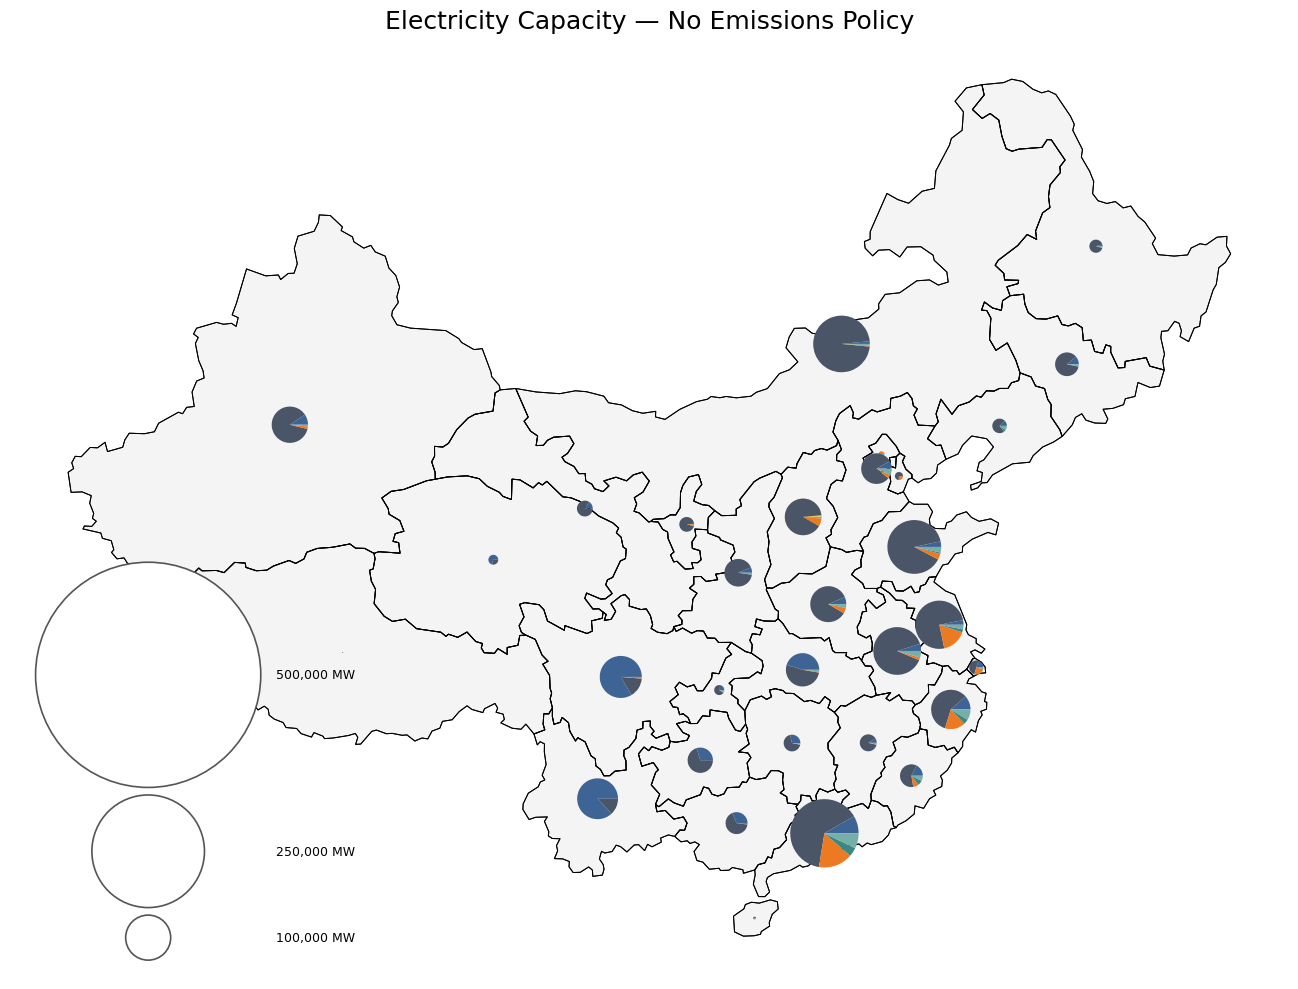

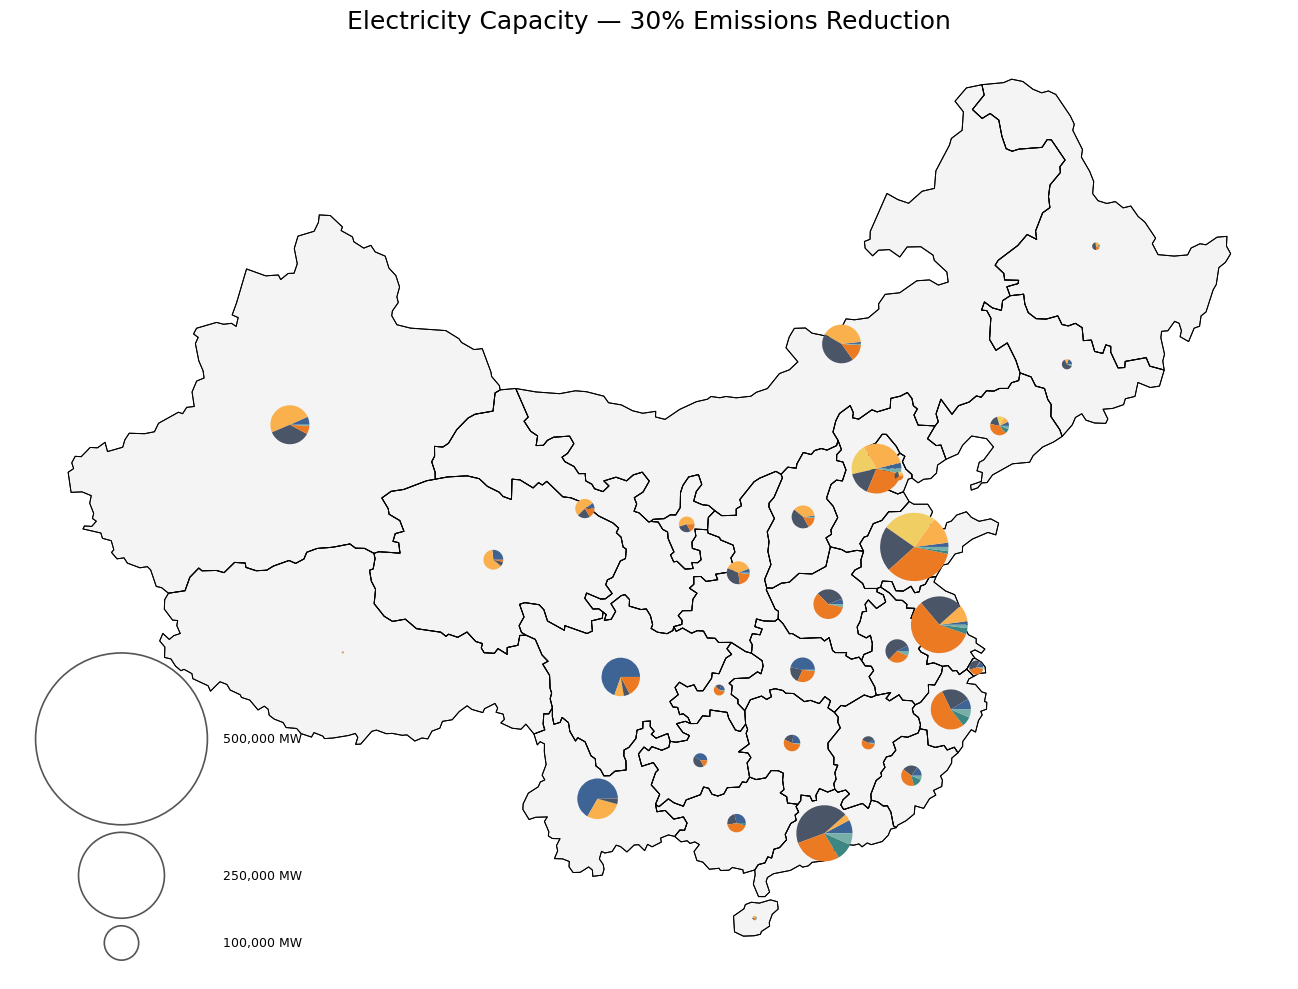

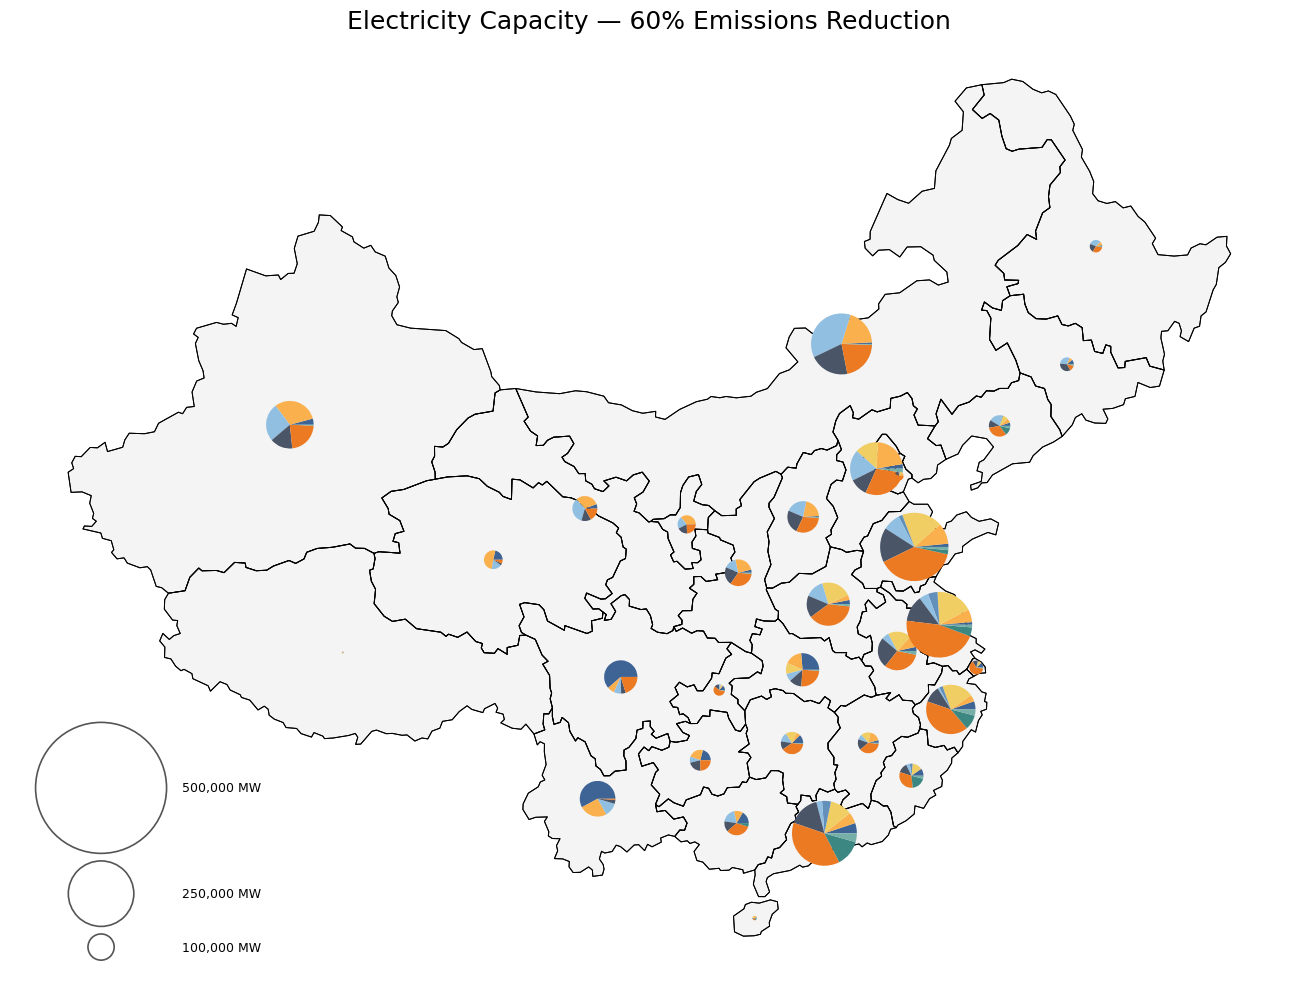

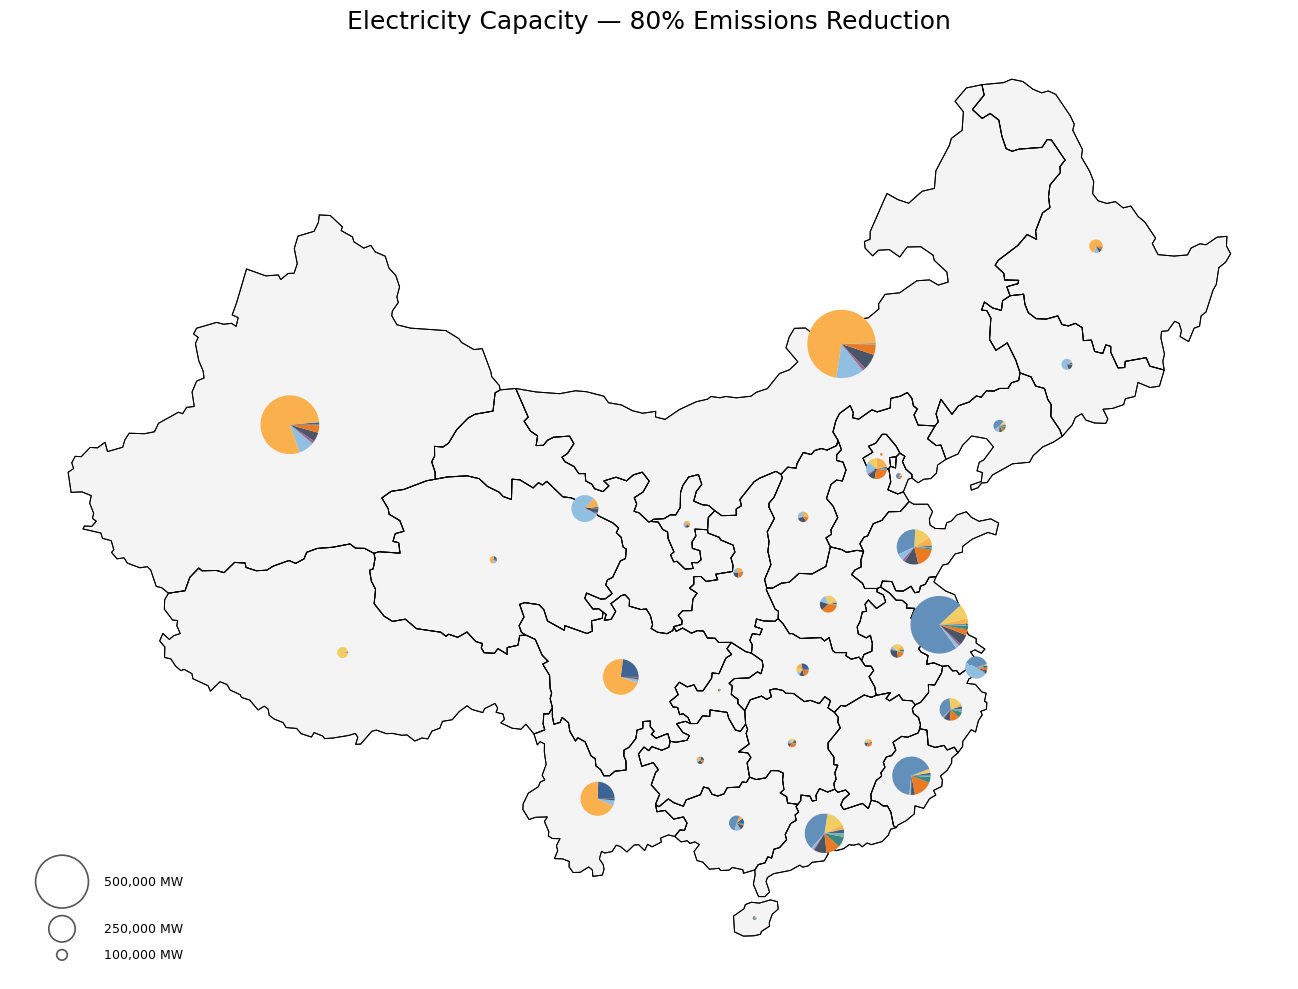

In [91]:
for case in cases:
    plot_province_pies(gdf, elec_df[case],
                       colors=custom_color_map,
                       pie_scale=2.5,
                       title=f"Electricity Capacity — {scenario_map[case]}",
                       legend_sizes=[100_000, 250_000, 500_000],
                       capacity_unit="MW")


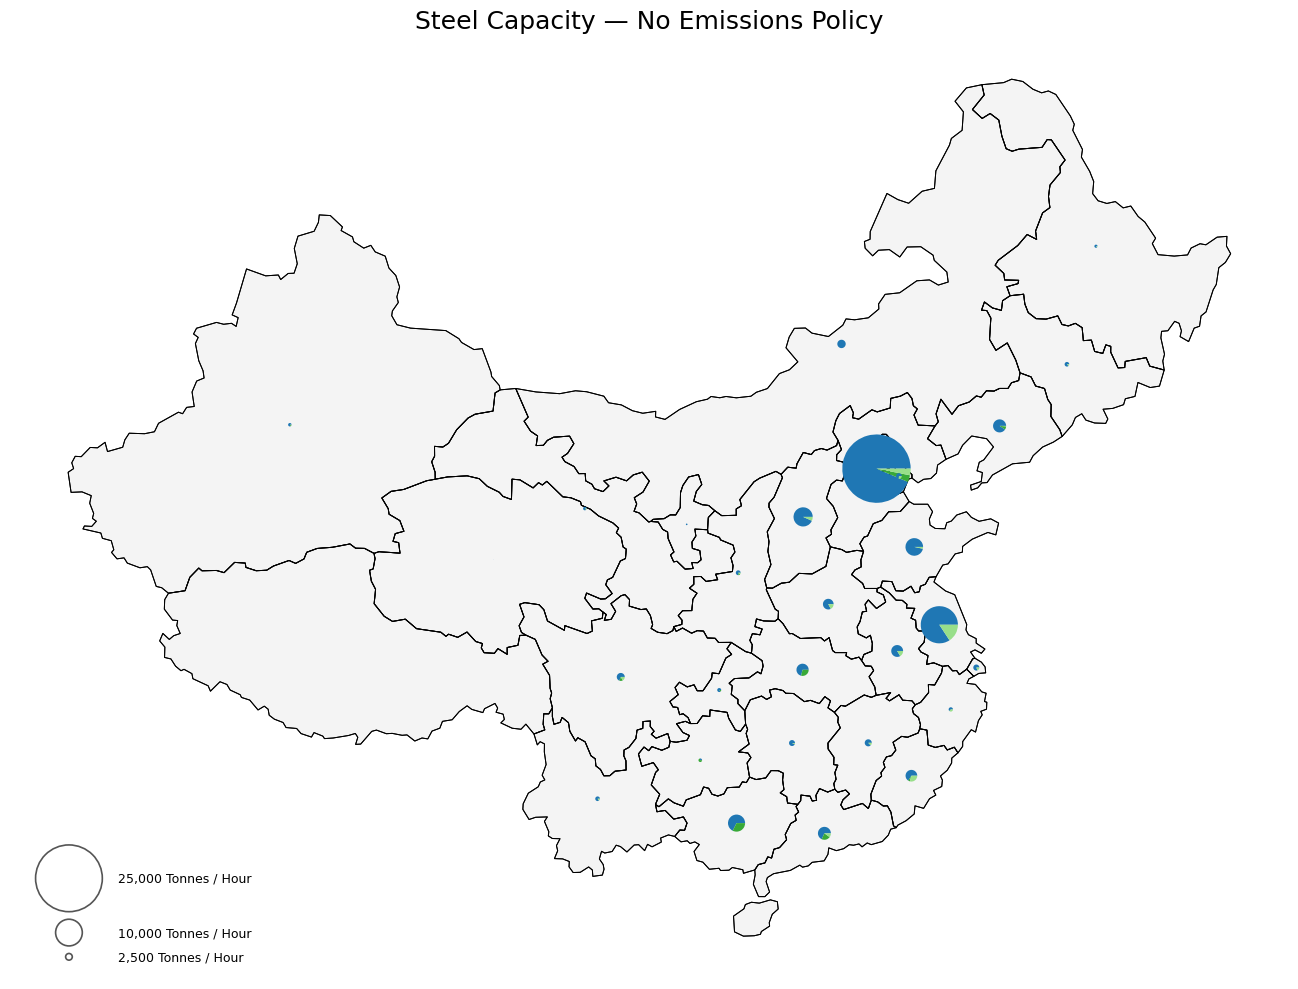

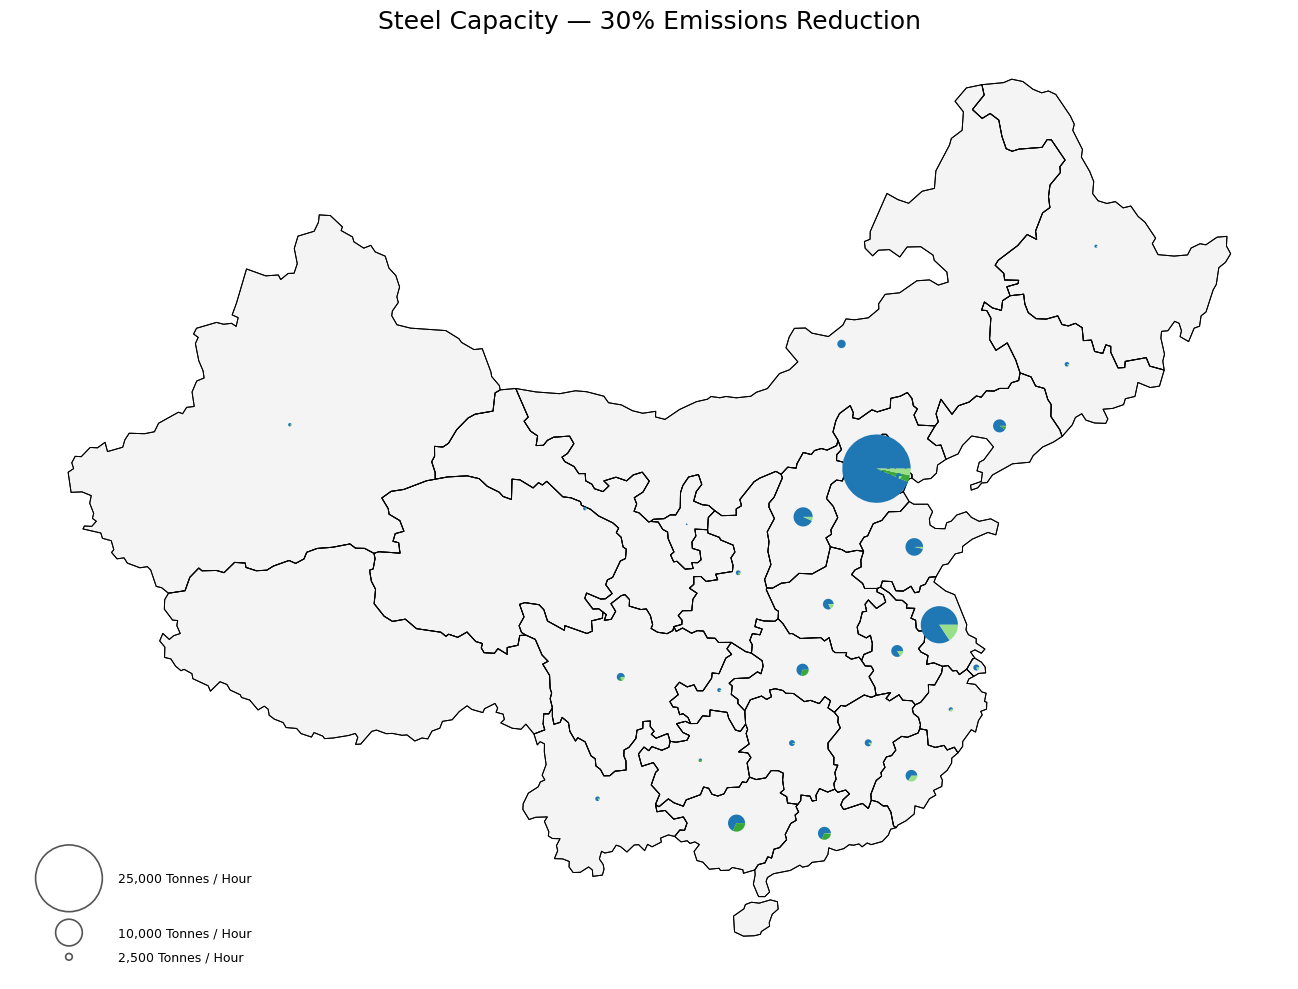

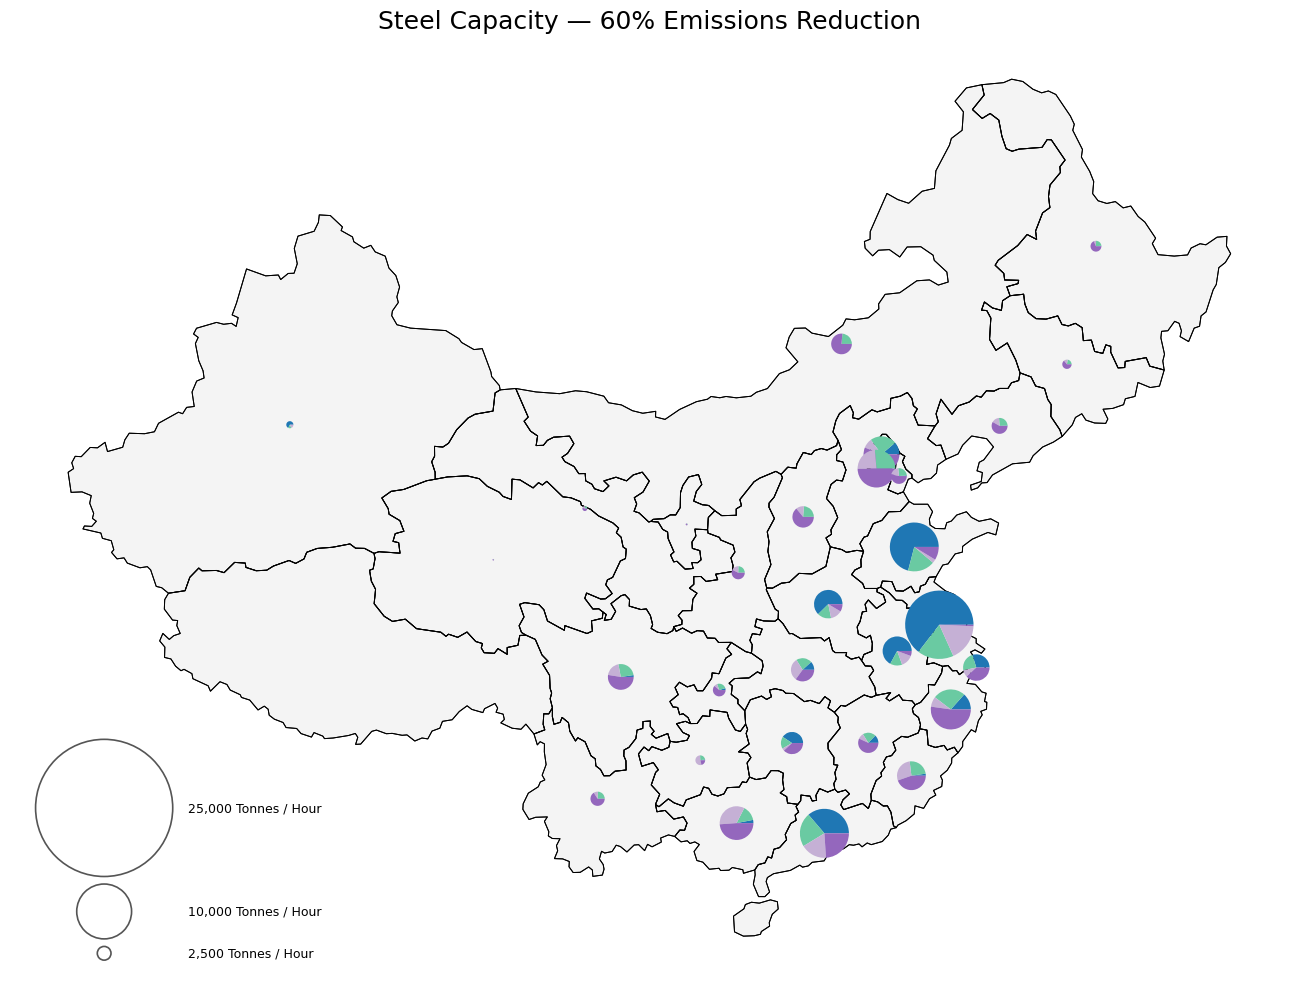

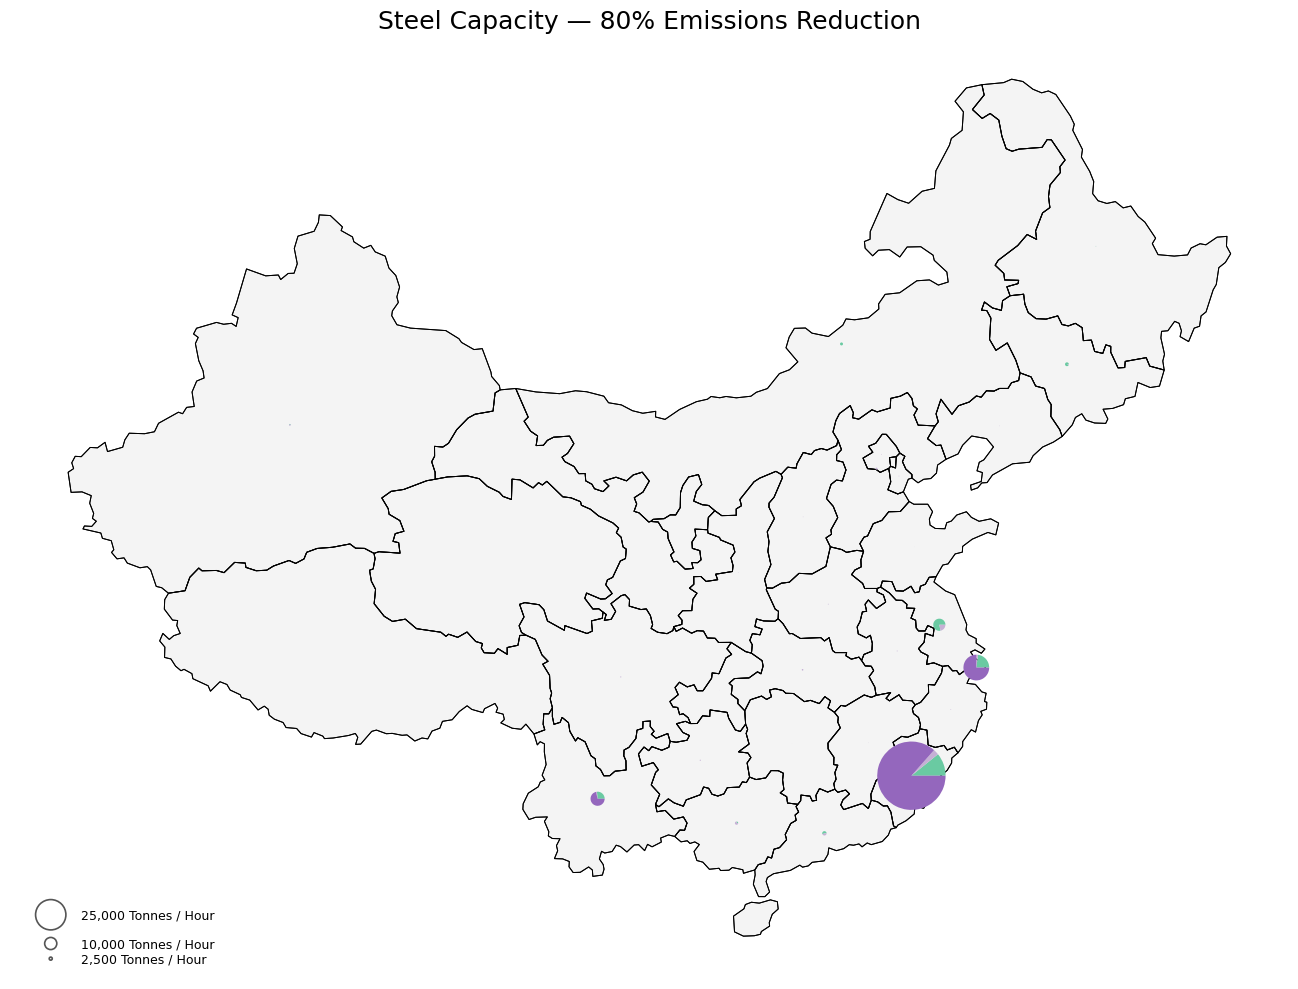

In [92]:
for case in cases:
    plot_province_pies(gdf, steel_df[case],
                       colors=custom_color_map,
                       pie_scale=2.5,
                       title=f"Steel Capacity — {scenario_map[case]}",
                       legend_sizes=[2_500, 10_000, 25_000],
                       capacity_unit="Tonnes / Hour")


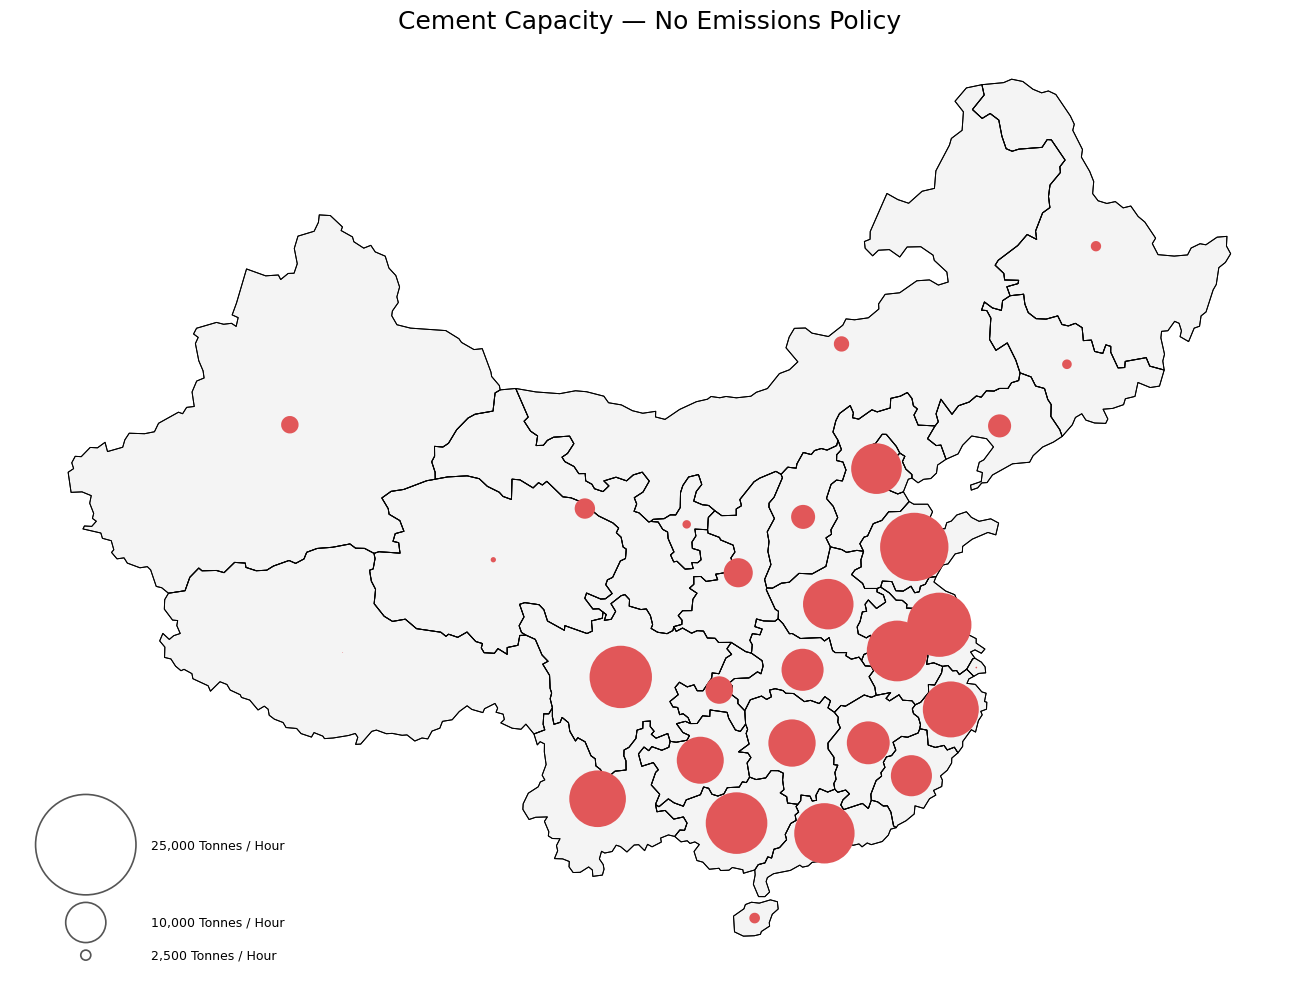

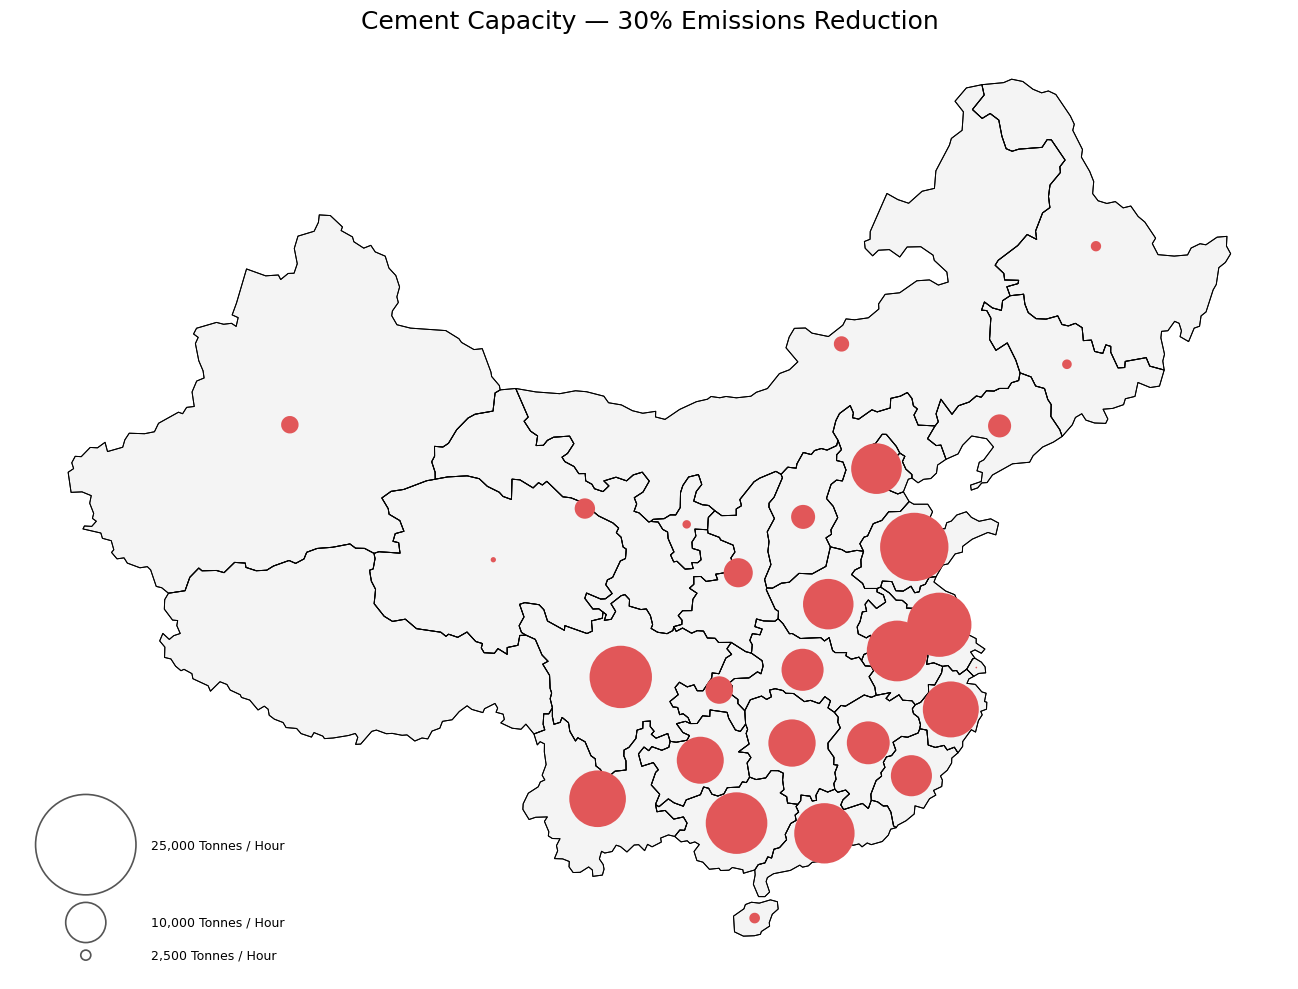

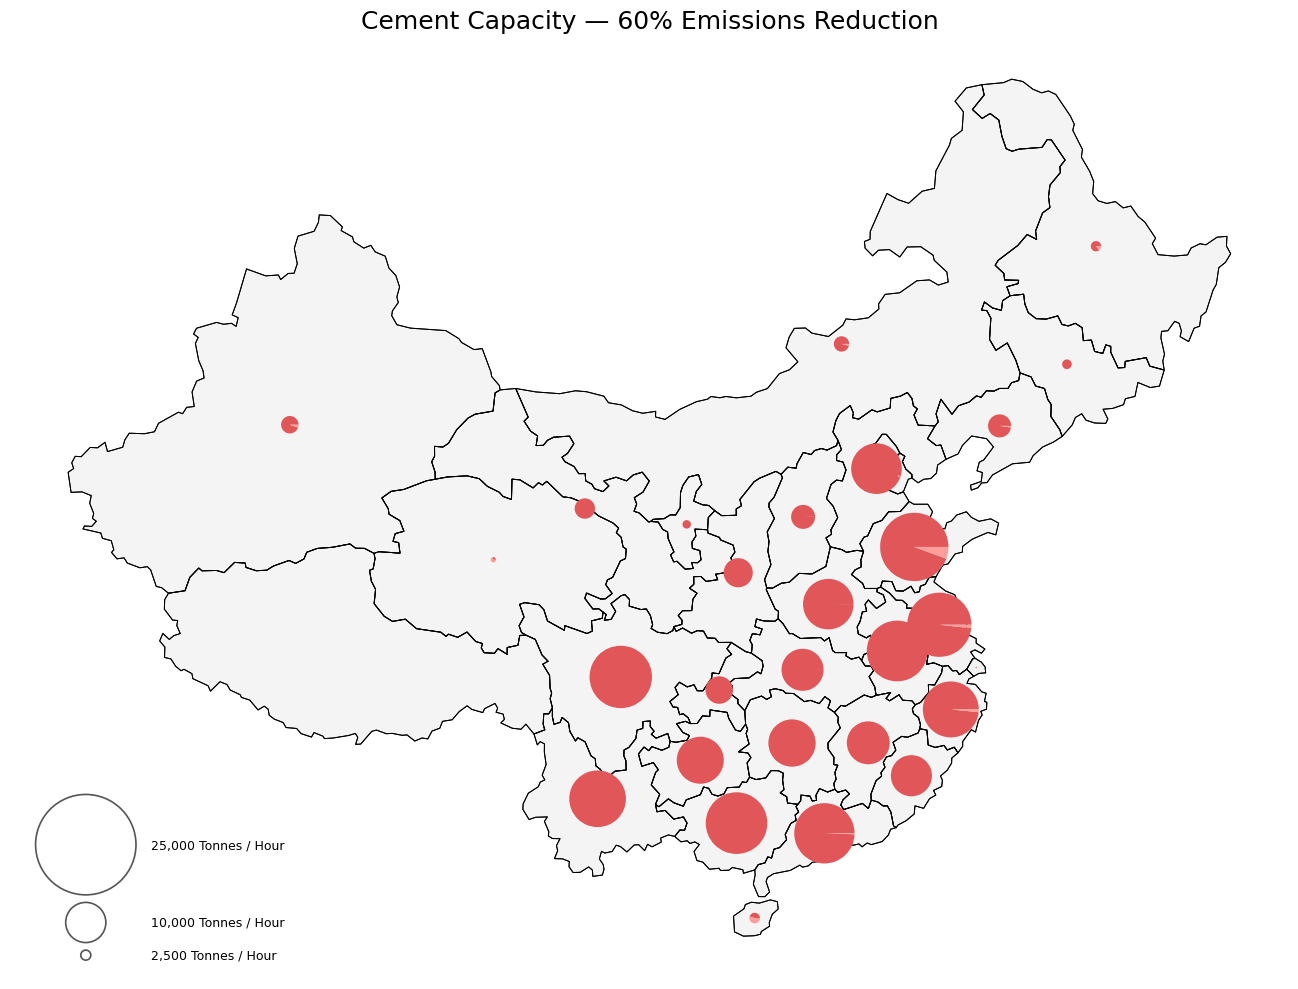

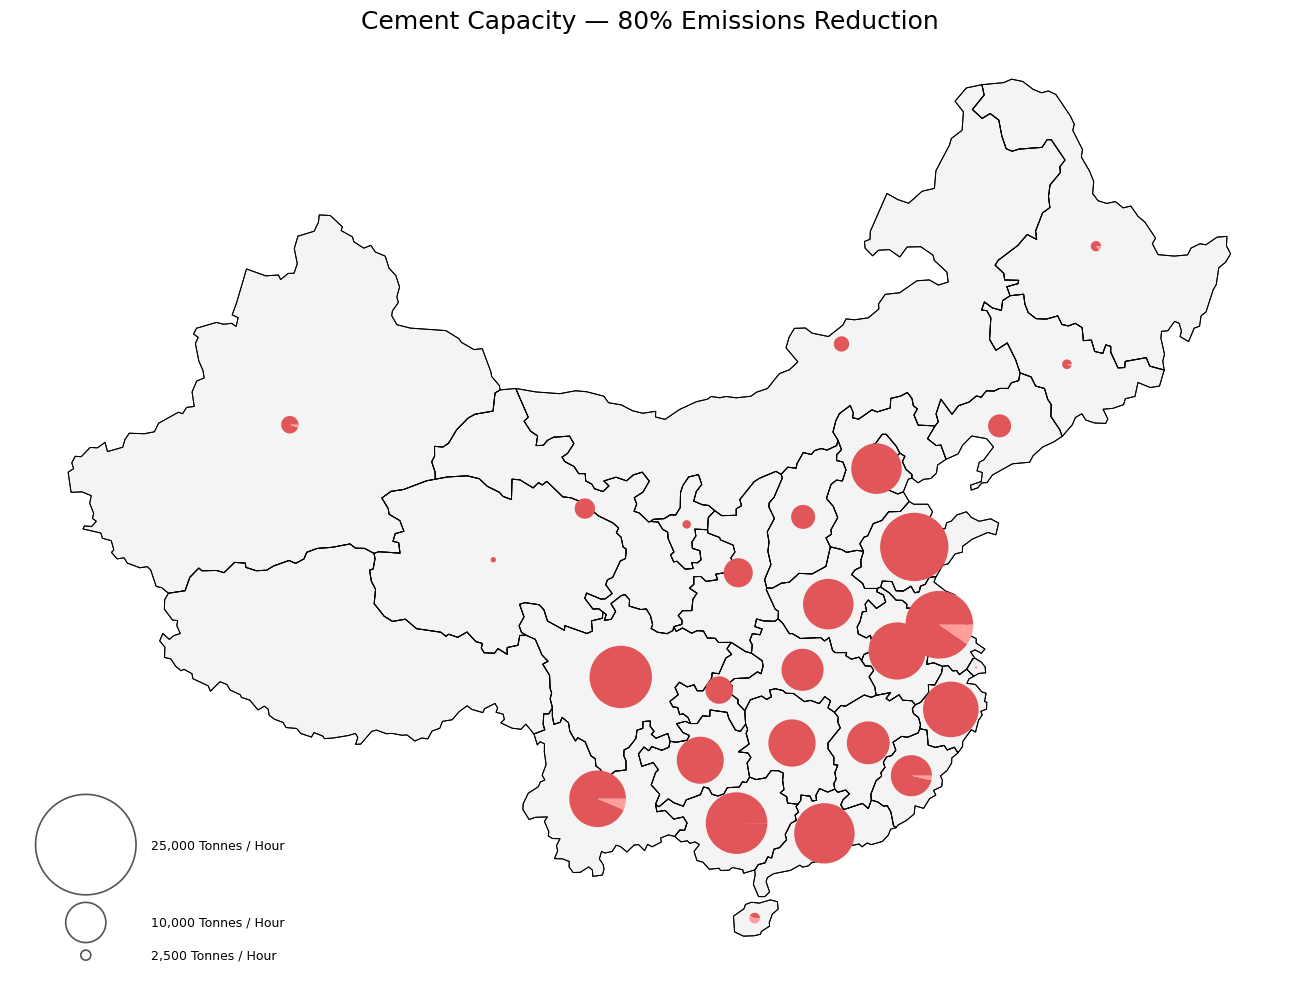

In [93]:
for case in cases:
    plot_province_pies(gdf, cement_df[case],
                       colors=custom_color_map,
                       pie_scale=2.5,
                       title=f"Cement Capacity — {scenario_map[case]}",
                       legend_sizes=[2_500, 10_000, 25_000],
                       capacity_unit="Tonnes / Hour")


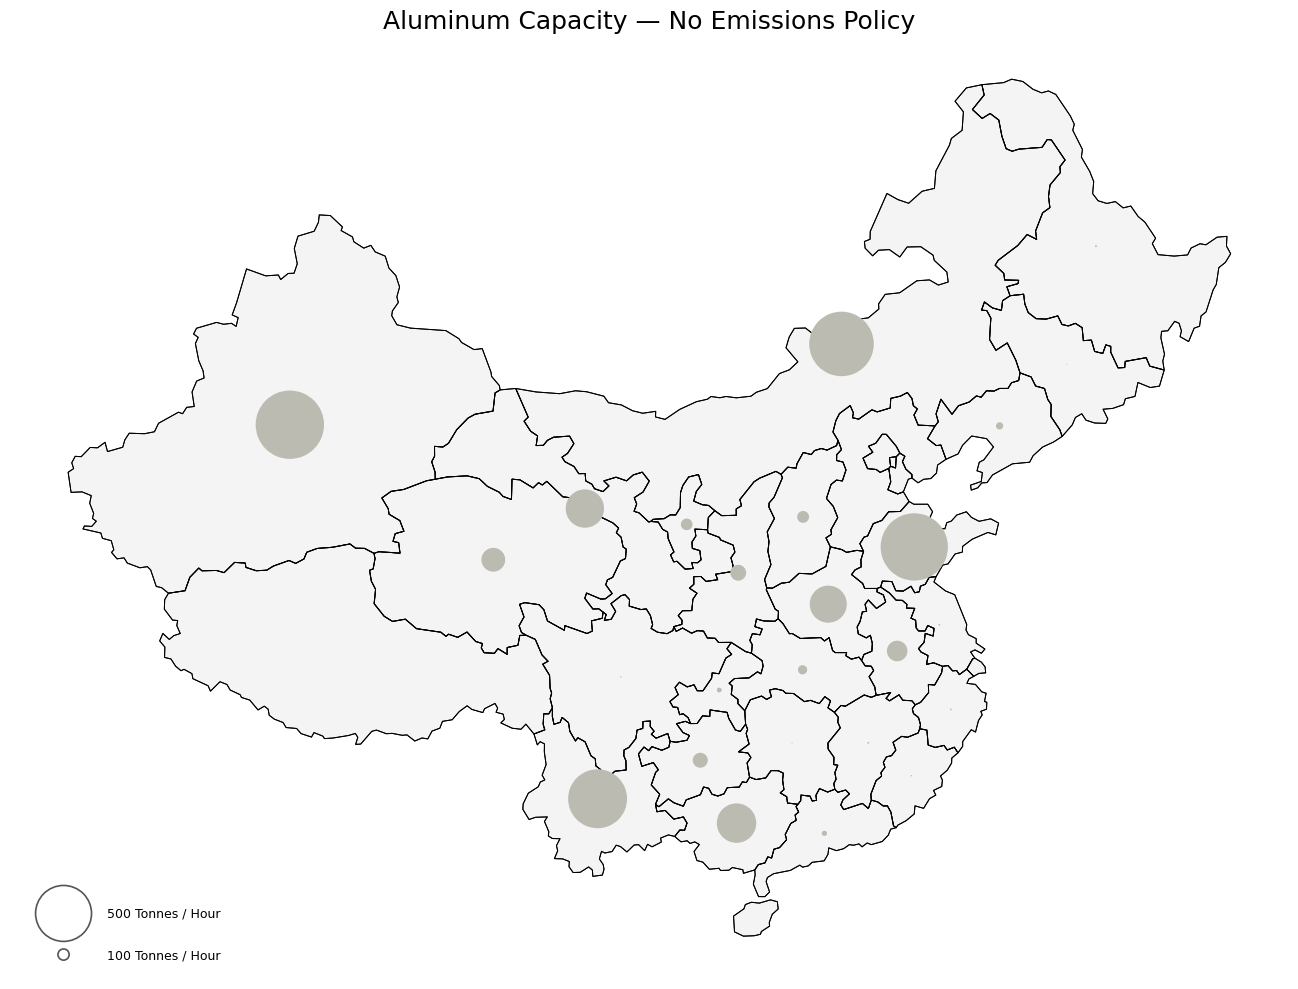

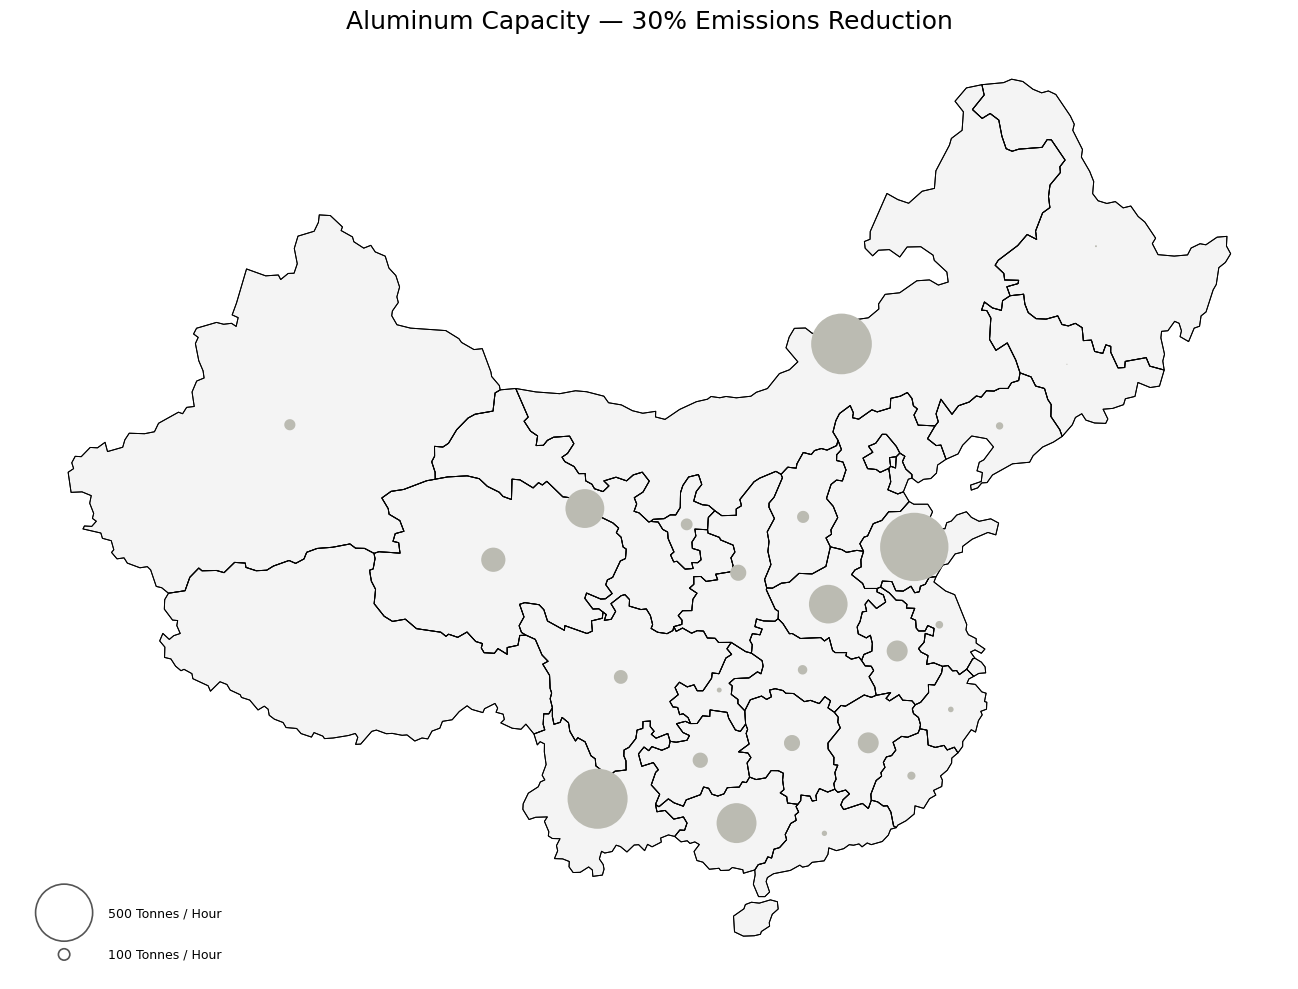

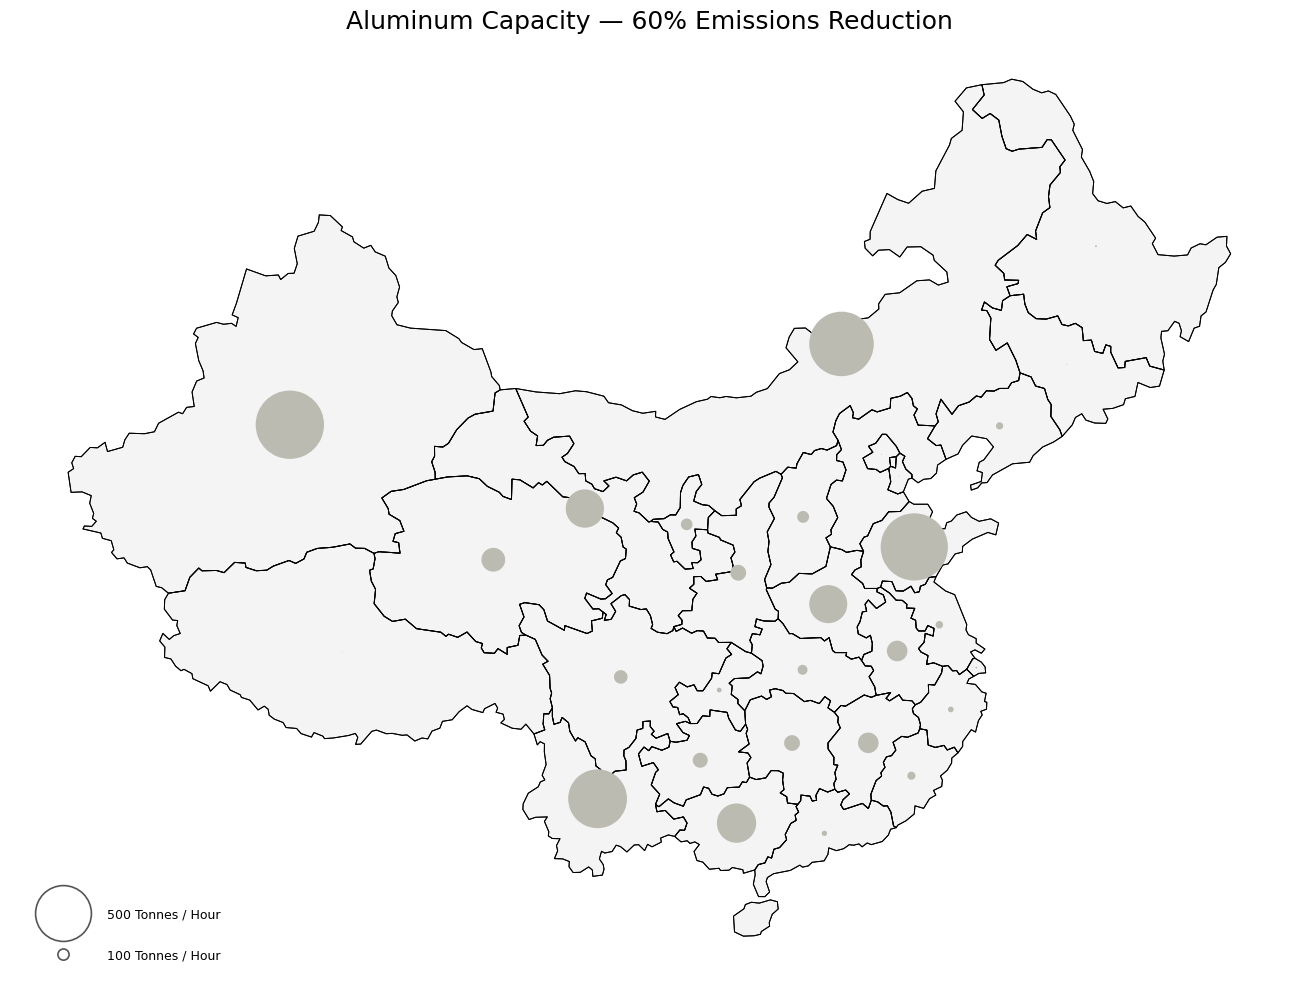

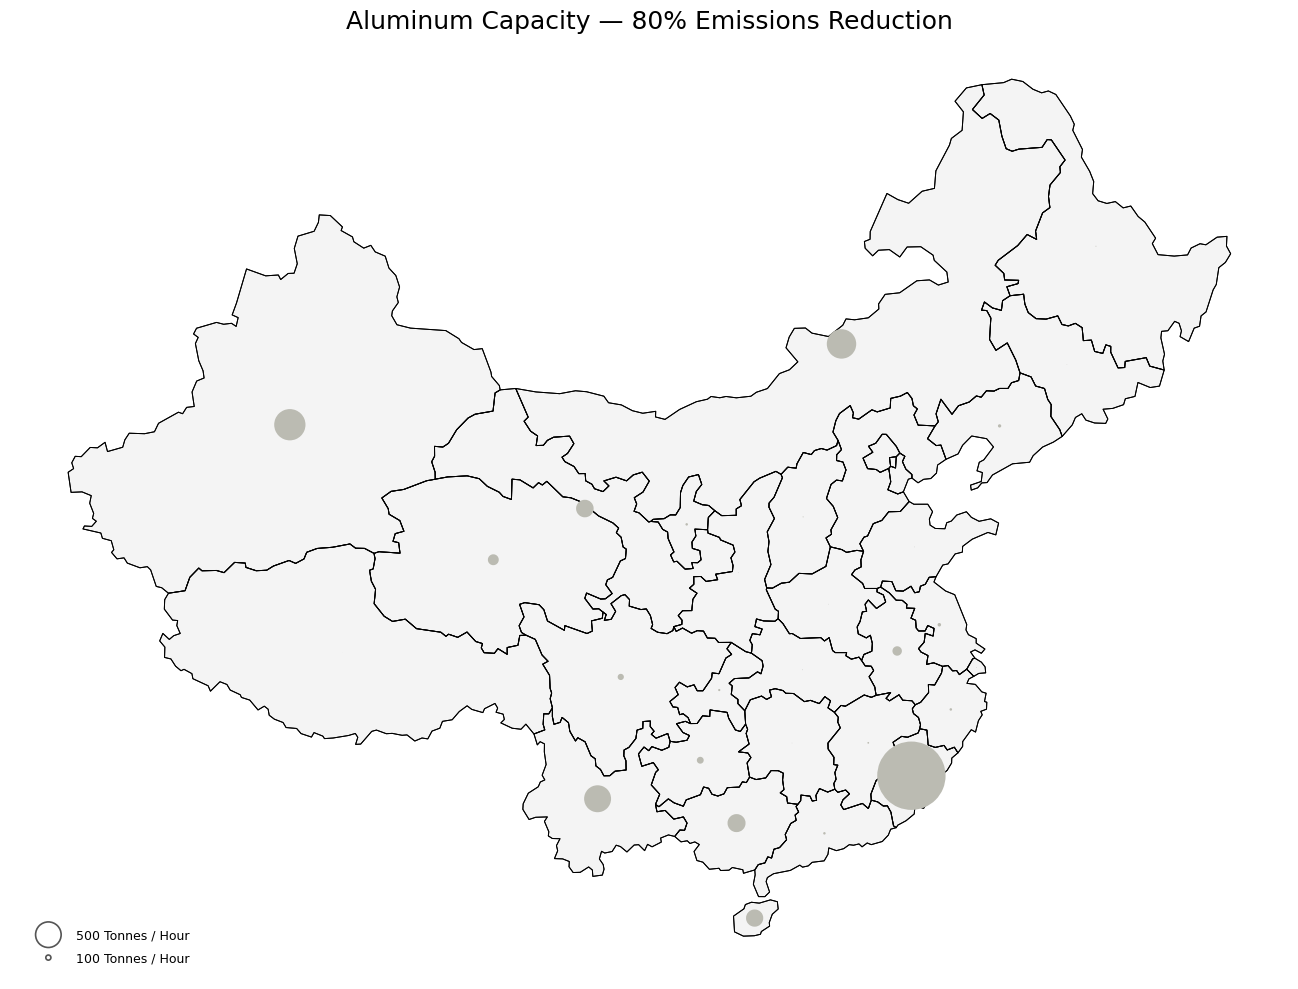

In [94]:
for case in cases:
    plot_province_pies(gdf, aluminum_df[case],
                       colors=custom_color_map,
                       pie_scale=2.5,
                       title=f"Aluminum Capacity — {scenario_map[case]}",
                       legend_sizes=[100, 500],
                       capacity_unit="Tonnes / Hour")


# Steel Material Transportation Flows

In [95]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

def plot_transport_flows(
    flows_df,
    transport_prefix,         # e.g. "steelscrap_transport", "dri_transport", "crudesteel_transport"
    gdf_input,
    province_col="NAME_1",
    title="Transport Flows",
    color="#1f77b4",
    figsize=(12, 10),
    flow_threshold=100,       # net flows below this are not drawn
    max_shaft_width=150_000,  # metres (EPSG:3857) for the largest flow
    min_shaft_width=20_000,
    head_width_ratio=2.5,     # arrowhead width = ratio × shaft width
    legend_sizes=None,        # e.g. [5_000, 50_000, 200_000]
    unit_label="Tonnes",
):
    """
    Plot net inter-province transport flows as solid filled arrows on a China map.
    Net flow = flow(A→B) − flow(B→A); only the dominant direction is drawn.
    Arrow style matches PowerPoint block arrows (filled polygon, shaft + head).
    """
    gdf = gdf_input.copy()

    # --- Collect matching columns ---
    col_pat = re.compile(
        rf"^{re.escape(transport_prefix)}_Region\d+\w+_to_Region\d+\w+_transmission_edge$"
    )
    transport_cols = [c for c in flows_df.columns if col_pat.match(c)]
    if not transport_cols:
        print(f"No columns found for prefix: {transport_prefix}")
        return

    flow_sums = flows_df[transport_cols].sum()

    # --- Build directed dict ---
    edge_pat = re.compile(
        rf"^{re.escape(transport_prefix)}_Region\d+(\w+)_to_Region\d+(\w+)_transmission_edge$"
    )
    directed = {}
    for col, val in flow_sums.items():
        m = edge_pat.match(col)
        if m:
            directed[(m.group(1), m.group(2))] = val

    # --- Net flows per unordered pair ---
    pairs_seen = set()
    net_flows = []
    for (src, dst), fwd in directed.items():
        if (dst, src) in pairs_seen or (src, dst) in pairs_seen:
            continue
        pairs_seen.add((src, dst))
        rev = directed.get((dst, src), 0.0)
        net = fwd - rev
        if abs(net) > flow_threshold:
            net_flows.append((src, dst, net) if net > 0 else (dst, src, -net))

    if not net_flows:
        print("No net flows above threshold.")
        return

    # --- Project + centroids ---
    gdf_proj = gdf.to_crs(epsg=3857)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    centroid_map = dict(zip(
        gdf_proj[province_col],
        zip(gdf_proj.centroid.x, gdf_proj.centroid.y)
    ))

    max_flow = max(f for _, _, f in net_flows)

    def shaft_w(flow):
        frac = (flow / max_flow) ** 0.5
        return min_shaft_width + frac * (max_shaft_width - min_shaft_width)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="#888888", linewidth=0.6, zorder=0)

    for src, dst, flow in sorted(net_flows, key=lambda x: x[2]):   # small first → large on top
        if src not in centroid_map or dst not in centroid_map:
            continue
        x0, y0 = centroid_map[src]
        x1, y1 = centroid_map[dst]
        dx, dy  = x1 - x0, y1 - y0
        dist    = np.hypot(dx, dy)

        sw = shaft_w(flow)
        hw = sw * head_width_ratio
        hl = min(dist * 0.32, hw * 1.4)    # head_length: capped at 32% of distance
        alpha = 0.45 + 0.55 * (flow / max_flow)

        ax.arrow(
            x0, y0, dx, dy,
            width=sw,
            head_width=hw,
            head_length=hl,
            length_includes_head=True,
            fc=color,
            ec="white",
            linewidth=0.5,
            alpha=alpha,
            zorder=5,
        )

    plt.title(title, fontsize=16, pad=12)

    # --- Manual size legend drawn directly on axes (like plot_province_pies) ---
    if legend_sizes is None:
        legend_sizes = [max_flow * f for f in [0.1, 0.5, 1.0]]

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    pw = xlim[1] - xlim[0]
    ph = ylim[1] - ylim[0]

    arrow_len  = pw * 0.09
    lx         = xlim[0] + pw * 0.02
    ly         = ylim[0] + ph * 0.03
    max_legend_sw = shaft_w(max(legend_sizes))

    for size in sorted(legend_sizes):
        sw = shaft_w(size)
        hw = sw * head_width_ratio
        hl = min(arrow_len * 0.32, hw * 1.4)

        ax.arrow(
            lx, ly, arrow_len, 0,
            width=sw, head_width=hw, head_length=hl,
            length_includes_head=True,
            fc=color, ec="white", linewidth=0.5, alpha=0.85,
            zorder=10,
        )
        ax.text(
            lx + arrow_len + pw * 0.01, ly,
            f"{size:,.0f} {unit_label}",
            va="center", ha="left", fontsize=9, zorder=11,
        )
        ly += max_legend_sw * 3.2

    # Legend title
    ax.text(
        lx, ly + max_legend_sw * 0.5,
        "Annual Net Flow",
        fontsize=9, fontweight="bold", zorder=11,
    )

    plt.tight_layout()
    plt.show()


In [96]:
gdf = gpd.read_file("../gadm36_CHN_1.json")

rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}
gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

# Keep flows_80 for transport flow plots below
flows_80 = flow_dfs["80pct"]

# --- Total materials transported (sum over time, all edges) for every case ---
transport_summary = {}
for case in cases:
    f = flow_dfs[case]
    transport_summary[case] = {
        "Cement":      f[[c for c in f.columns if "cement_transport" in c and "transmission_edge" in c]].sum().sum(),
        "Scrap Steel": f[[c for c in f.columns if "steelscrap_transport" in c and "transmission_edge" in c]].sum().sum(),
        "DRI":         f[[c for c in f.columns if "dri_transport" in c and "transmission_edge" in c]].sum().sum(),
        "Crude Steel": f[[c for c in f.columns if "crudesteel_transport" in c and "transmission_edge" in c]].sum().sum(),
        "CO2":         f[[c for c in f.columns if "CO2_Pipeline_transmission_edge" in c]].sum().sum(),
    }

transport_summary_df = pd.DataFrame(transport_summary).T
transport_summary_df.index.name = "Case"
print("Total annual transport by material (Tonnes):\n")
print(transport_summary_df.applymap(lambda x: f"{x:,.0f}").to_string())


Total annual transport by material (Tonnes):

                   Cement Scrap Steel        DRI Crude Steel        CO2
Case                                                                   
noemissionscap    873,666   1,461,153      1,842  10,029,576         58
30pct             874,476   1,484,996      2,696   9,988,013        224
60pct             878,392      30,344      5,724   1,168,634  1,160,265
80pct           1,199,302   4,084,706  3,358,697  24,233,529  1,161,263


/var/folders/kh/f9wk57gd0fdfn4y132cdphgw0000gp/T/ipykernel_8614/859579410.py:29: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [ ]:
for case in cases:
    plot_transport_flows(
        flows_df=flow_dfs[case],
        transport_prefix="cement_transport",
        gdf_input=gdf,
        title=f"Cement Transport — {scenario_map[case]}",
        color="#e15759",
        figsize=(12, 10),
        legend_sizes=[5_000, 50_000, 200_000],
        unit_label="Tonnes"
    )


In [ ]:
for case in cases:
    plot_transport_flows(
        flows_df=flow_dfs[case],
        transport_prefix="steelscrap_transport",
        gdf_input=gdf,
        title=f"Scrap Steel Transport — {scenario_map[case]}",
        color="#38a938",
        figsize=(12, 10),
        legend_sizes=[5_000, 50_000, 200_000],
        unit_label="Tonnes",
        flow_threshold=5000
    )


In [ ]:
for case in cases:
    plot_transport_flows(
        flows_df=flow_dfs[case],
        transport_prefix="dri_transport",
        gdf_input=gdf,
        title=f"DRI Transport — {scenario_map[case]}",
        color="#9467bd",
        figsize=(12, 10),
        legend_sizes=[5_000, 50_000, 200_000],
        unit_label="Tonnes",
        flow_threshold=5000
    )


In [ ]:
for case in cases:
    plot_transport_flows(
        flows_df=flow_dfs[case],
        transport_prefix="crudesteel_transport",
        gdf_input=gdf,
        title=f"Crude Steel Transport — {scenario_map[case]}",
        color="#1f77b4",
        figsize=(12, 10),
        legend_sizes=[5_000, 50_000, 200_000],
        unit_label="Tonnes",
        flow_threshold=5000
    )


In [ ]:
from pyproj import Transformer

# Basin centroids (lon, lat) from usgs_source/basin_centroids_shapefile.csv
BASIN_COORDS = {
    "Songliao":        (124.2489, 45.5424),
    "TurpanHami":      (91.8474,  42.7741),
    "Subei":           (120.2968, 33.2802),
    "BohaiOnshore":    (117.027,  38.1531),
    "Qaidam":          (94.0675,  37.4565),
    "Nanxiang":        (112.3891, 32.6284),
    "Sanjiang":        (132.0,    47.0   ),
    "Hailar":          (118.5403, 48.9011),
    "Jianghan":        (112.9206, 30.4742),
    "Tarim":           (82.2819,  39.3991),
    "Ordos":           (108.7178, 37.5548),
    "YingenEjina":     (101.5,    41.5   ),
    "Hehuai":          (115.0,    34.0   ),
    "Qinshui":         (112.4531, 36.7143),
    "Erlian":          (115.3402, 44.1892),
    "Junggar":         (87.0998,  44.9779),
    "SichuanBasin":    (105.9742, 30.357 ),
    "BohaiOffshore":   (119.7405, 39.0081),
    "NorthYellowSea":  (123.3029, 38.3492),
    "SouthYellowSea":  (123.0614, 35.6424),
    "EastChinaSea":    (124.815,  29.2425),
    "PearlRiverMouth": (114.5827, 20.6148),
    "BeibugGulf":      (109.1529, 20.3578),
    "Qiongdongnan":    (110.6,    17.9   ),
}

def plot_co2_transport_flows(
    flows_df,
    gdf_input,
    province_col="NAME_1",
    title="CO2 Transport Flows",
    color="#4a5568",
    figsize=(13, 11),
    flow_threshold=100,
    max_shaft_width=80_000,
    min_shaft_width=8_000,
    head_width_ratio=2.5,
    legend_sizes=None,
    unit_label="Tonnes",
):
    """
    Plot CO2 pipeline flows from province centroids to CO2 storage basin locations.
    Column pattern: Region{N}{Province}_to_{Basin}_CO2_Pipeline_transmission_edge
    Basin coordinates sourced from usgs_source/basin_centroids_shapefile.csv.
    """
    transformer = Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)
    basin_xy = {name: transformer.transform(lon, lat) for name, (lon, lat) in BASIN_COORDS.items()}

    col_pat = re.compile(r"^Region\d+(\w+)_to_(\w+)_CO2_Pipeline_transmission_edge$")
    flows = {}
    for col in flows_df.columns:
        m = col_pat.match(col)
        if m:
            province, basin = m.group(1), m.group(2)
            val = flows_df[col].sum()
            if val > flow_threshold:
                flows[(province, basin)] = flows.get((province, basin), 0) + val

    if not flows:
        print("No CO2 transport flows found above threshold.")
        return

    gdf = gdf_input.copy().to_crs(epsg=3857)
    gdf["centroid"] = gdf.geometry.centroid
    centroid_map = dict(zip(gdf[province_col], zip(gdf.centroid.x, gdf.centroid.y)))

    max_flow = max(flows.values())

    def shaft_w(flow):
        frac = (flow / max_flow) ** 0.5
        return min_shaft_width + frac * (max_shaft_width - min_shaft_width)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    gdf.plot(ax=ax, color="#F4F4F4", edgecolor="#888888", linewidth=0.6, zorder=0)

    for (province, basin), flow in sorted(flows.items(), key=lambda x: x[1]):
        if province not in centroid_map or basin not in basin_xy:
            continue
        x0, y0 = centroid_map[province]
        x1, y1 = basin_xy[basin]
        dx, dy  = x1 - x0, y1 - y0
        dist    = np.hypot(dx, dy)
        sw = shaft_w(flow)
        hw = sw * head_width_ratio
        hl = min(dist * 0.30, hw * 1.4)
        alpha = 0.30 + 0.70 * (flow / max_flow)
        ax.arrow(x0, y0, dx, dy,
                 width=sw, head_width=hw, head_length=hl,
                 length_includes_head=True,
                 fc=color, ec="white", linewidth=0.4,
                 alpha=alpha, zorder=5)

    # Mark basin locations
    for name, (bx, by) in basin_xy.items():
        ax.plot(bx, by, "v", color="#e15759", markersize=6, zorder=10, clip_on=False)
        ax.text(bx, by + 50_000, name, fontsize=6, ha="center", va="bottom", zorder=11, clip_on=False)

    plt.title(title, fontsize=16, pad=12)

    if legend_sizes is None:
        legend_sizes = [max_flow * f for f in [0.1, 0.5, 1.0]]

    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    pw = xlim[1] - xlim[0]; ph = ylim[1] - ylim[0]
    arrow_len = pw * 0.09
    lx = xlim[0] + pw * 0.02
    ly = ylim[0] + ph * 0.03
    max_legend_sw = shaft_w(max(legend_sizes))

    for size in sorted(legend_sizes):
        sw = shaft_w(size)
        hw = sw * head_width_ratio
        hl = min(arrow_len * 0.32, hw * 1.4)
        ax.arrow(lx, ly, arrow_len, 0,
                 width=sw, head_width=hw, head_length=hl,
                 length_includes_head=True,
                 fc=color, ec="white", linewidth=0.5, alpha=0.85, zorder=10)
        ax.text(lx + arrow_len + pw * 0.01, ly,
                f"{size:,.0f} {unit_label}", va="center", ha="left", fontsize=9, zorder=11)
        ly += max_legend_sw * 3.2

    ax.text(lx, ly + max_legend_sw * 0.5, "Annual Flow",
            fontsize=9, fontweight="bold", zorder=11)

    plt.tight_layout()
    plt.show()


for case in cases:
    plot_co2_transport_flows(
        flows_df=flow_dfs[case],
        gdf_input=gdf,
        title=f"CO2 Pipeline Transport — {scenario_map[case]}",
        color="#4a5568",
        figsize=(13, 11),
        legend_sizes=[500_000, 2_000_000, 5_000_000],
        unit_label="Tonnes",
        flow_threshold=100000,
    )
